In [19]:
# Module
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from model.lsclib import caseClass, find_caseKey
from fractions import Fraction

In [20]:
# User specified parameters
ustar_all = (0.01214, 0.00857, 0.00605)
  # m/s

H = 25 # m
Lx = 600 # m
Ly = 600 # m

In [21]:
Laₜ = 0.35
χ = Fraction(1, 2)
kH = Fraction(5, 2)

path_data = "./"
fmt_dir = "Lat{Lat:s}_X{X:s}_kH{kH:s}"
fmt_fn = "conditionalAverage_{type_ud:s}welling.npz"

if Laₜ == np.inf:
    case = caseClass(Laₜ, χ, 0, ustar_all[0], H)
else:
    case = caseClass(Laₜ, χ, kH, ustar_all[0], H)

dir_case = os.path.join(path_data, case.key_case)

path_fn = os.path.join(dir_case, fmt_fn.format(type_ud='up'))
data_u1 = np.load(path_fn)

path_fn = os.path.join(dir_case, fmt_fn.format(type_ud='down'))
data_d1= np.load(path_fn)

In [22]:
Laₜ = 0.35
χ = Fraction(1, 2)
kH = Fraction(10, 1)

path_data = "./"
fmt_dir = "Lat{Lat:s}_X{X:s}_kH{kH:s}"
fmt_fn = "conditionalAverage_{type_ud:s}welling.npz"

if Laₜ == np.inf:
    case = caseClass(Laₜ, χ, 0, ustar_all[0], H)
else:
    case = caseClass(Laₜ, χ, kH, ustar_all[0], H)

dir_case = os.path.join(path_data, case.key_case)

path_fn = os.path.join(dir_case, fmt_fn.format(type_ud='up'))
data_u2 = np.load(path_fn)

path_fn = os.path.join(dir_case, fmt_fn.format(type_ud='down'))
data_d2 = np.load(path_fn)

In [23]:
Laₜ = 0.7
χ = Fraction(2, 1)
kH = Fraction(10, 1)

path_data = "./"
fmt_dir = "Lat{Lat:s}_X{X:s}_kH{kH:s}"
fmt_fn = "conditionalAverage_{type_ud:s}welling.npz"

if Laₜ == np.inf:
    case = caseClass(Laₜ, χ, 0, ustar_all[0], H)
else:
    case = caseClass(Laₜ, χ, kH, ustar_all[2], H)

dir_case = os.path.join(path_data, case.key_case)

path_fn = os.path.join(dir_case, fmt_fn.format(type_ud='up'))
data_u3 = np.load(path_fn)

path_fn = os.path.join(dir_case, fmt_fn.format(type_ud='down'))
data_d3 = np.load(path_fn)

In [24]:
Laₜ = np.inf
χ = Fraction(1, 1)
kH = np.inf

path_data = "./"
fmt_dir = "Lat{Lat:s}_X{X:s}_kH{kH:s}"
fmt_fn = "conditionalAverage_{type_ud:s}welling.npz"

if Laₜ == np.inf:
    case = caseClass(Laₜ, χ, 0, ustar_all[0], H)
else:
    case = caseClass(Laₜ, χ, kH, ustar_all[0], H)

dir_case = os.path.join(path_data, case.key_case)

path_fn = os.path.join(dir_case, fmt_fn.format(type_ud='up'))
data_u4 = np.load(path_fn)

path_fn = os.path.join(dir_case, fmt_fn.format(type_ud='down'))
data_d4 = np.load(path_fn)

In [25]:
Laₜ = 0.35
χ = Fraction(2, 1)
kH = Fraction(5, 2)

path_data = "./"
fmt_dir = "Lat{Lat:s}_X{X:s}_kH{kH:s}"
fmt_fn = "conditionalAverage_{type_ud:s}welling.npz"

if Laₜ == np.inf:
    case = caseClass(Laₜ, χ, 0, ustar_all[0], H)
else:
    case = caseClass(Laₜ, χ, kH, ustar_all[2], H)

dir_case = os.path.join(path_data, case.key_case)

path_fn = os.path.join(dir_case, fmt_fn.format(type_ud='up'))
data_u5 = np.load(path_fn)

path_fn = os.path.join(dir_case, fmt_fn.format(type_ud='down'))
data_d5 = np.load(path_fn)

In [26]:
Laₜ = 0.7
χ = Fraction(1, 2)
kH = Fraction(5, 2)

path_data = "./"
fmt_dir = "Lat{Lat:s}_X{X:s}_kH{kH:s}"
fmt_fn = "conditionalAverage_{type_ud:s}welling.npz"

if Laₜ == np.inf:
    case = caseClass(Laₜ, χ, 0, ustar_all[0], H)
else:
    case = caseClass(Laₜ, χ, kH, ustar_all[2], H)

dir_case = os.path.join(path_data, case.key_case)

path_fn = os.path.join(dir_case, fmt_fn.format(type_ud='up'))
data_u6 = np.load(path_fn)

path_fn = os.path.join(dir_case, fmt_fn.format(type_ud='down'))
data_d6 = np.load(path_fn)

In [9]:
# Create axis
nz_w, ny, nx = data_u1["w"].shape
nz_uv = data_u1["u_E"].shape[0]

x_1d = np.arange(Lx/nx/2, Lx, Lx/nx) / H - Lx / H / 2
y_1d = np.arange(Ly/ny/2, Ly, Ly/nx) / H - Ly / H / 2
zw_1d = np.arange(-1, 0+1/(nz_w-1)/2, 1/(nz_w-1))
zuv_1d = np.arange(-1+1/nz_uv/2, 0, 1/nz_uv)

In [10]:
def calc_tke(data, u_key="u_E", v_key="v", w_key="w", avg_axis=(-2, -1)):
    """
    计算湍动能 (TKE)
    
    参数:
    data : dict
        包含速度场数据的字典 (例如 data_u1)
    u_key, v_key, w_key : str
        速度分量在字典中的键名
    avg_axis : tuple
        求空间平均的维度 (默认 -2, -1 即水平面 x, y 维度)
    interpolate_w : bool
        是否将 w 从交错网格(面心)插值到体心。
        - False (默认): 保持你原来的做法，直接丢弃最后一层 `[:-1,:,:]`
        - True: 使用上下两层求平均插值 `0.5*(w[:-1] + w[1:])`
    
    返回:
    tke : ndarray
        计算得到的 TKE 3D 数组
    """
    # 1. 计算 u 和 v 的脉动
    u_prime = data[u_key] - np.mean(data[u_key], axis=avg_axis, keepdims=True)
    v_prime = data[v_key] - np.mean(data[v_key], axis=avg_axis, keepdims=True)
    
    # 2. 处理 w 及其脉动
    w_raw = data[w_key]
    w_center = 0.5 * (w_raw[:-1, :, :] + w_raw[1:, :, :])
    w_prime = w_center - np.mean(w_center, axis=avg_axis, keepdims=True)
    
    # 3. 计算 TKE (加上标准的 0.5 系数)
    tke = 0.5 * (u_prime**2 + v_prime**2 + w_prime**2)
    
    return tke

In [22]:
def plot_field3d(ax, x, y, z, field3d, kw, ustar):
    x3d, y3d, z3d = np.meshgrid(x, y, z, indexing='ij')
    x3d, y3d, z3d = x3d.T, y3d.T, z3d.T
    field3d = field3d / ustar

    ax.contourf(x3d[-5,:,:], y3d[-5,:,:], field3d[-5,:,:],
                zdir='z', offset=z3d[-4,0,0], **kw)
    ax.contourf(x3d[:,0,:], field3d[:,0,:], z3d[:,0,:],
                zdir='y', offset=x3d.min(), **kw)
    cax = ax.contourf(field3d[:,:,-1], y3d[:,:,-1], z3d[:,:,-1],
                      zdir='x', offset=y3d.max(), **kw)

    ax.set_xlim(-12.2, 12.2)
    ax.set_ylim(-12.2, 12.2)
    ax.set_zlim(-1.05, 0.05)
    ax.set_zticks([-1, -0.5, 0])
    ax.view_init(30, -20, 0)
    ax.set_box_aspect((5, 5, 2), zoom=1)
    return cax


def plot_field3d_tke(ax, x, y, z, field3d, kw, ustar):
    x3d, y3d, z3d = np.meshgrid(x, y, z, indexing='ij')
    x3d, y3d, z3d = x3d.T, y3d.T, z3d.T
    field3d = field3d / ustar**2

    ax.contourf(x3d[-5,:,:], y3d[-5,:,:], field3d[-5,:,:],
                zdir='z', offset=z3d[-4,0,0], **kw)
    ax.contourf(x3d[:,0,:], field3d[:,0,:], z3d[:,0,:],
                zdir='y', offset=x3d.min(), **kw)
    cax = ax.contourf(field3d[:,:,-1], y3d[:,:,-1], z3d[:,:,-1],
                      zdir='x', offset=y3d.max(), **kw)

    ax.set_xlim(-12.2, 12.2)
    ax.set_ylim(-12.2, 12.2)
    ax.set_zlim(-1.05, 0.05)
    ax.set_zticks([-1, -0.5, 0])
    ax.view_init(30, -20, 0)
    ax.set_box_aspect((5, 5, 2), zoom=1)
    return cax

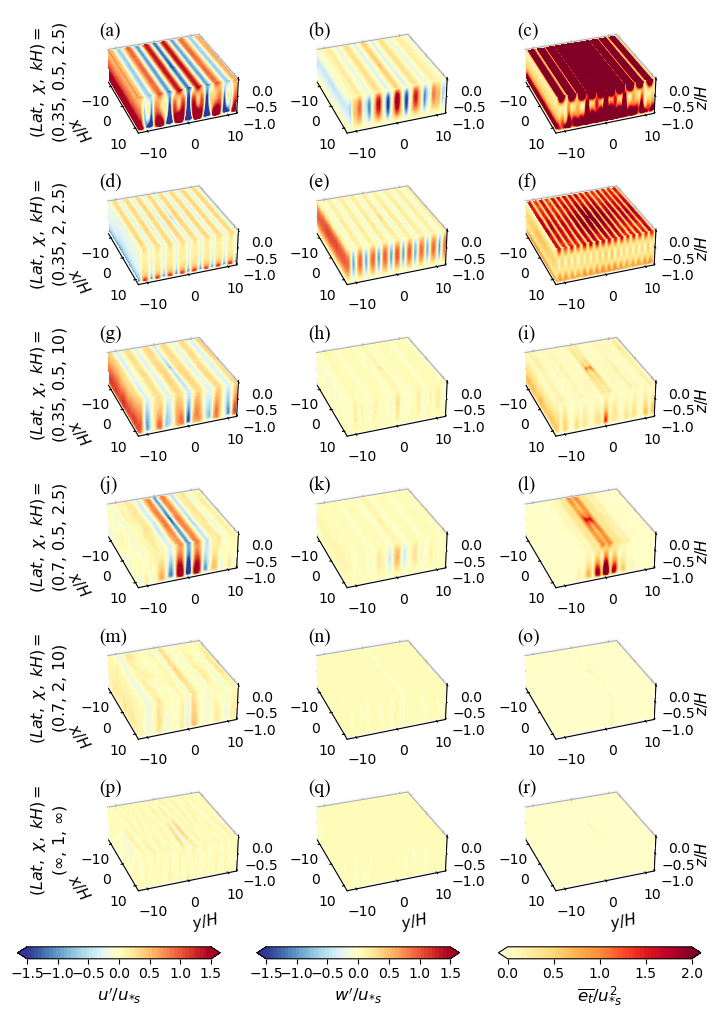

In [29]:
# ============================================================
# TKE
# ============================================================
tke1, tke2, tke3 = calc_tke(data_u1), calc_tke(data_u2), calc_tke(data_u3)
tke4, tke5, tke6 = calc_tke(data_u4), calc_tke(data_u5), calc_tke(data_u6)

# ============================================================
# Figure / GridSpec
# ============================================================
fig = plt.figure(figsize=(7.5, 10))
gs = fig.add_gridspec(6, 3,wspace=0.0,hspace=0.05)

# 给四周和底部 colorbar 预留空间
fig.subplots_adjust(left=0.12,right=0.955,top=0.997,bottom=0.095)


# ============================================================
# Contour settings
# ============================================================
kw = {
    'vmin': -1.5, 'vmax': 1.5,
    'levels': np.linspace(-1.5, 1.5, 51),
    'cmap': plt.get_cmap("RdYlBu_r"),
    'extend': 'both'
}

kw2 = {
    'vmin': 0, 'vmax': 2,
    'levels': np.linspace(0, 2, 51),
    'cmap': plt.get_cmap("YlOrRd"),
    'extend': 'both'
}

# ============================================================
# Case information
# ============================================================
cases = [
    (r"$(0.35,\,0.5,\,2.5)$", data_u1, tke1, ustar_all[0]),
    (r"$(0.35,\,2,\,2.5)$",   data_u5, tke5, ustar_all[0]),
    (r"$(0.35,\,0.5,\,10)$",  data_u2, tke2, ustar_all[2]),
    (r"$(0.7,\,0.5,\,2.5)$",  data_u6, tke6, ustar_all[0]),
    (r"$(0.7,\,2,\,10)$",     data_u3, tke3, ustar_all[2]),
    (r"$(\infty,\,1,\,\infty)$", data_u4, tke4, ustar_all[0])
]

letters = list("abcdefghijklmnopqr")


# ============================================================
# Draw all panels
# ============================================================
axes = []
cax_u = cax_w = cax_tke = None

for i, (case_label, data, tke, ustar) in enumerate(cases):
    row = i

    # --------------------------------------------------------
    # u_E'
    # --------------------------------------------------------
    ax = fig.add_subplot(gs[row, 0], projection='3d')
    du = data["u_E"] - np.mean(data["u_E"], axis=(-2, -1), keepdims=True)
    cax_u = plot_field3d(ax, x_1d, y_1d, zuv_1d, du, kw, ustar)
    axes.append(ax)

    # panel label
    ax.text2D(0.02, 0.92, f"({letters[i*3]})",fontfamily='Times New Roman',
              transform=ax.transAxes, fontsize=14, va='top')

    # case label
    ax.text2D(-0.33, 0.50,
              r"$(Lat,\ \chi,\ kH) =$" + "\n" + case_label,
              transform=ax.transAxes, rotation=90,
              va='center', ha='center', fontsize=11.5,fontweight='bold')

    # --------------------------------------------------------
    # w'
    # --------------------------------------------------------
    ax = fig.add_subplot(gs[row, 1], projection='3d')
    dw = data["w"] - np.mean(data["w"], axis=(-2, -1), keepdims=True)
    cax_w = plot_field3d(ax, x_1d, y_1d, zw_1d, dw, kw, ustar)
    axes.append(ax)

    ax.text2D(0.02, 0.92, f"({letters[i*3+1]})",
              transform=ax.transAxes, fontsize=14,
              fontfamily='Times New Roman', va='top')

    # --------------------------------------------------------
    # TKE
    # --------------------------------------------------------
    ax = fig.add_subplot(gs[row, 2], projection='3d')
    cax_tke = plot_field3d_tke(ax, x_1d, y_1d, zuv_1d, tke, kw2, ustar)
    axes.append(ax)

    ax.text2D(0.02, 0.92, f"({letters[i*3+2]})",
              transform=ax.transAxes, fontsize=14,
              fontfamily='Times New Roman', va='top')


# ============================================================
# Axis labels
# 只在最下面一行显示，避免 18 个子图全部挤在一起
# ============================================================
for ax in axes[0::3]:
    ax.set_xlabel(r'$x/H$', fontsize=11, labelpad=3)

axes[15].set_ylabel(r'$y/H$', fontsize=11, labelpad=3)
axes[16].set_ylabel(r'$y/H$', fontsize=11, labelpad=3)
axes[17].set_ylabel(r'$y/H$', fontsize=11, labelpad=3)

# 每一列只在最右侧显示 z/H，避免重复

for ax in axes[2::3]:
    ax.text2D(
        1.3, 0.40,
        r'$z/H$',
        transform=ax.transAxes,
        rotation=90,
        fontsize=11,
        va='center',
        ha='center')

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=10, pad=1)
    ax.tick_params(axis='z', which='major', labelsize=10, pad=1)

# ============================================================
# Colorbars
# ============================================================
cbar_ax_u = fig.add_axes([0.058, 0.048, 0.27, 0.012])
cbar_ax_w = fig.add_axes([0.377, 0.048, 0.27, 0.012])
cbar_ax_tke = fig.add_axes([0.699, 0.048, 0.27, 0.012])

cbar_u = fig.colorbar(
    cax_u, cax=cbar_ax_u, orientation='horizontal',
    ticks=np.arange(-1.5, 1.51, 0.5)
)
cbar_w = fig.colorbar(
    cax_w, cax=cbar_ax_w, orientation='horizontal',
    ticks=np.arange(-1.5, 1.51, 0.5)
)
cbar_tke = fig.colorbar(
    cax_tke, cax=cbar_ax_tke, orientation='horizontal',
    ticks=np.arange(0, 2.01, 0.5)
)

for cb in [cbar_u, cbar_w, cbar_tke]:
    cb.ax.tick_params(labelsize=10, pad=2)

cbar_u.set_label(r"$u'/u_{*s}$", fontsize=12, labelpad=3)
cbar_w.set_label(r"$w'/u_{*s}$", fontsize=12, labelpad=3)
cbar_tke.set_label(r"$\overline{e_t}/u_{*s}^{2}$", fontsize=12, labelpad=3)


# ============================================================
# Save
# ============================================================
fig.savefig(
    "condAvg_3D_upwelling.png",
    dpi=300,
    bbox_inches='tight',
    # pad_inches=0.2
)

plt.show()

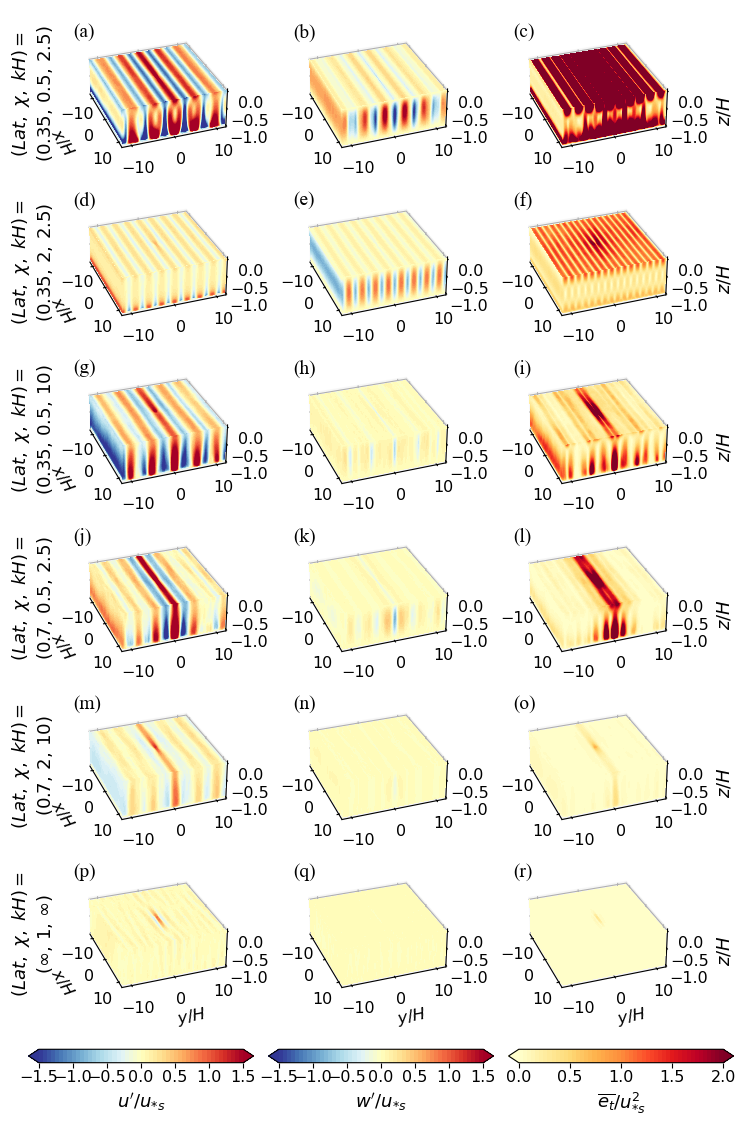

In [75]:
# ============================================================
# TKE
# ============================================================
tke1, tke2, tke3 = calc_tke(data_d1), calc_tke(data_d2), calc_tke(data_d3)
tke4, tke5, tke6 = calc_tke(data_d4), calc_tke(data_d5), calc_tke(data_d6)

# ============================================================
# Figure / GridSpec
# ============================================================
fig = plt.figure(figsize=(7.5, 11))
gs = fig.add_gridspec(6, 3,wspace=0.0,hspace=0.0)

# 给四周和底部 colorbar 预留空间
fig.subplots_adjust(left=0.075,right=0.955,top=0.985,bottom=0.085)


# ============================================================
# Contour settings
# ============================================================
kw = {
    'vmin': -1.5, 'vmax': 1.5,
    'levels': np.linspace(-1.5, 1.5, 51),
    'cmap': plt.get_cmap("RdYlBu_r"),
    'extend': 'both'
}

kw2 = {
    'vmin': 0, 'vmax': 2,
    'levels': np.linspace(0, 2, 51),
    'cmap': plt.get_cmap("YlOrRd"),
    'extend': 'both'
}

# ============================================================
# Case information
# ============================================================
cases = [
    (r"$(0.35,\,0.5,\,2.5)$", data_d1, tke1, ustar_all[0]),
    (r"$(0.35,\,2,\,2.5)$",   data_d5, tke5, ustar_all[0]),
    (r"$(0.35,\,0.5,\,10)$",  data_d2, tke2, ustar_all[2]),
    (r"$(0.7,\,0.5,\,2.5)$",  data_d6, tke6, ustar_all[0]),
    (r"$(0.7,\,2,\,10)$",     data_d3, tke3, ustar_all[2]),
    (r"$(\infty,\,1,\,\infty)$", data_d4, tke4, ustar_all[0])
]

letters = list("abcdefghijklmnopqr")


# ============================================================
# Draw all panels
# ============================================================
axes = []
cax_u = cax_w = cax_tke = None

for i, (case_label, data, tke, ustar) in enumerate(cases):
    row = i

    # --------------------------------------------------------
    # u_E'
    # --------------------------------------------------------
    ax = fig.add_subplot(gs[row, 0], projection='3d')
    du = data["u_E"] - np.mean(data["u_E"], axis=(-2, -1), keepdims=True)
    cax_u = plot_field3d(ax, x_1d, y_1d, zuv_1d, du, kw, ustar)
    axes.append(ax)

    # panel label
    ax.text2D(0.02, 0.92, f"({letters[i*3]})",fontfamily='Times New Roman',
              transform=ax.transAxes, fontsize=14, va='top')

    # case label
    ax.text2D(-0.24, 0.50,
              r"$(Lat,\ \chi,\ kH) =$" + "\n" + case_label,
              transform=ax.transAxes, rotation=90,
              va='center', ha='center', fontsize=13)

    # --------------------------------------------------------
    # w'
    # --------------------------------------------------------
    ax = fig.add_subplot(gs[row, 1], projection='3d')
    dw = data["w"] - np.mean(data["w"], axis=(-2, -1), keepdims=True)
    cax_w = plot_field3d(ax, x_1d, y_1d, zw_1d, dw, kw, ustar)
    axes.append(ax)

    ax.text2D(0.02, 0.92, f"({letters[i*3+1]})",
              transform=ax.transAxes, fontsize=14,
              fontfamily='Times New Roman', va='top')

    # --------------------------------------------------------
    # TKE
    # --------------------------------------------------------
    ax = fig.add_subplot(gs[row, 2], projection='3d')
    cax_tke = plot_field3d_tke(ax, x_1d, y_1d, zuv_1d, tke, kw2, ustar)
    axes.append(ax)

    ax.text2D(0.02, 0.92, f"({letters[i*3+2]})",
              transform=ax.transAxes, fontsize=14,
              fontfamily='Times New Roman', va='top')


# ============================================================
# Axis labels
# 只在最下面一行显示，避免 18 个子图全部挤在一起
# ============================================================
for ax in axes[0::3]:
    ax.set_xlabel(r'$x/H$', fontsize=12, labelpad=3)

axes[15].set_ylabel(r'$y/H$', fontsize=12, labelpad=5)
axes[16].set_ylabel(r'$y/H$', fontsize=12, labelpad=5)
axes[17].set_ylabel(r'$y/H$', fontsize=12, labelpad=5)

# 每一列只在最右侧显示 z/H，避免重复

for ax in axes[2::3]:
    ax.text2D(
        1.28, 0.40,
        r'$z/H$',
        transform=ax.transAxes,
        rotation=90,
        fontsize=13,
        va='center',
        ha='center')

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=11.5, pad=2)
    ax.tick_params(axis='z', which='major', labelsize=11.5, pad=2)

# ============================================================
# Colorbars
# ============================================================
cbar_ax_u = fig.add_axes([0.055, 0.045, 0.3, 0.012])
cbar_ax_w = fig.add_axes([0.375, 0.045, 0.3, 0.012])
cbar_ax_tke = fig.add_axes([0.695, 0.045, 0.3, 0.012])

cbar_u = fig.colorbar(
    cax_u, cax=cbar_ax_u, orientation='horizontal',
    ticks=np.arange(-1.5, 1.51, 0.5)
)
cbar_w = fig.colorbar(
    cax_w, cax=cbar_ax_w, orientation='horizontal',
    ticks=np.arange(-1.5, 1.51, 0.5)
)
cbar_tke = fig.colorbar(
    cax_tke, cax=cbar_ax_tke, orientation='horizontal',
    ticks=np.arange(0, 2.01, 0.5)
)

for cb in [cbar_u, cbar_w, cbar_tke]:
    cb.ax.tick_params(labelsize=11.5, pad=2)

cbar_u.set_label(r"$u'/u_{*s}$", fontsize=13, labelpad=4)
cbar_w.set_label(r"$w'/u_{*s}$", fontsize=13, labelpad=4)
cbar_tke.set_label(r"$\overline{e_t}/u_{*s}^{2}$", fontsize=13, labelpad=4)


# ============================================================
# Save
# ============================================================
fig.savefig(
    "condAvg_3D_downwelling.png",
    dpi=300,
    # bbox_inches='tight',
    # pad_inches=0.2
)

plt.show()

### Normalized by TKE^(1/2)

In [1]:
import os
import pandas as pd
import numpy as np
from fractions import Fraction
from model.lsclib import caseClass, find_caseKey
import matplotlib as mpl
import matplotlib.pyplot as plt

# ============================================================
# 0. Settings
# ============================================================
path_data = "G:/LSCDynRegime_cxy/data"
bn_data = "statistics.feather"

La_t_all = (0.35, 0.7, np.inf)
chi_all = (Fraction(1, 2), Fraction(3, 4), Fraction(1, 1),
           Fraction(4, 3), Fraction(2, 1))
kH_all = (Fraction(5, 2), Fraction(5, 1), Fraction(10, 1))
ustar_all = (0.01214, 0.00857, 0.00605)

H = 25
Lx = 600
Ly = 600

# ============================================================
# 1. Create case containers
# ============================================================
case_all = dict()

for La_t in La_t_all:
    for chi in chi_all:
        if La_t == np.inf:
            case = caseClass(La_t, chi, 0, ustar_all[0], H)
            case_all[case.key_case] = case
        else:
            for ik, kH in enumerate(kH_all):
                case = caseClass(La_t, chi, kH, ustar_all[ik], H)
                case_all[case.key_case] = case

# ============================================================
# 2. Read statistics.feather and calculate tke12_les
# ============================================================
tke12_by_case = {}

for case in case_all:
    fn = os.path.join(path_data, case, bn_data)
    data_col = pd.read_feather(fn)

    tke_mean = data_col["tke+"].mean()
    tke12_by_case[case] = np.sqrt(tke_mean)

    print(f"{case}: tke12_les = {tke12_by_case[case]:.6f}")

# ============================================================
# 3. Load six conditional-average cases
# ============================================================
# ============================================================
# Load data
# ============================================================
def load_case(La_t, chi, kH, ustar):
    if La_t == np.inf:
        case = caseClass(La_t, chi, 0, ustar, H)
    else:
        case = caseClass(La_t, chi, kH, ustar, H)
    dir_case = os.path.join(path_data, case.key_case)
    data_u = np.load(os.path.join(dir_case, "conditionalAverage_upwelling.npz"))
    data_d = np.load(os.path.join(dir_case, "conditionalAverage_downwelling.npz"))
    return data_u, data_d

data_u1, data_d1 = load_case(0.35, Fraction(1, 2), Fraction(5, 2), ustar_all[0])
data_u2, data_d2 = load_case(0.35, Fraction(1, 2), Fraction(10, 1), ustar_all[2])
data_u3, data_d3 = load_case(0.7, Fraction(2, 1), Fraction(10, 1), ustar_all[2])
data_u4, data_d4 = load_case(np.inf, Fraction(1, 1), np.inf, ustar_all[0])
data_u5, data_d5 = load_case(0.35, Fraction(2, 1), Fraction(5, 2), ustar_all[0])
data_u6, data_d6 = load_case(0.7, Fraction(1, 2), Fraction(5, 2), ustar_all[0])

# ============================================================
# TKE calculation
# ============================================================
def calc_tke(data, u_key="u_E", v_key="v", w_key="w", avg_axis=(-2, -1)):
    u_prime = data[u_key] - np.mean(data[u_key], axis=avg_axis, keepdims=True)
    v_prime = data[v_key] - np.mean(data[v_key], axis=avg_axis, keepdims=True)
    w_raw = data[w_key]
    w_center = 0.5 * (w_raw[:-1, :, :] + w_raw[1:, :, :])
    w_prime = w_center - np.mean(w_center, axis=avg_axis, keepdims=True)
    return 0.5 * (u_prime**2 + v_prime**2 + w_prime**2)

tke1, tke2, tke3 = calc_tke(data_d1), calc_tke(data_d2), calc_tke(data_d3)
tke4, tke5, tke6 = calc_tke(data_d4), calc_tke(data_d5), calc_tke(data_d6)

# Here we only associate each case with its corresponding
# tke12_les obtained from statistics.feather.

case_keys = [ caseClass(0.35, Fraction(1,2), Fraction(5,2), ustar_all[0], H).key_case, 
             caseClass(0.35, Fraction(2,1), Fraction(5,2), ustar_all[0], H).key_case, 
             caseClass(0.35, Fraction(1,2), Fraction(10,1), ustar_all[2], H).key_case, 
             caseClass(0.7, Fraction(1,2), Fraction(5,2), ustar_all[0], H).key_case, 
             caseClass(0.7, Fraction(2,1), Fraction(10,1), ustar_all[2], H).key_case, 
             caseClass(np.inf, Fraction(1,1), 0, ustar_all[0], H).key_case ]

tke12_les1 = tke12_by_case[case_keys[0]]*ustar_all[0]
tke12_les2 = tke12_by_case[case_keys[1]]*ustar_all[0]
tke12_les3 = tke12_by_case[case_keys[2]]*ustar_all[2]
tke12_les4 = tke12_by_case[case_keys[3]]*ustar_all[0]
tke12_les5 = tke12_by_case[case_keys[4]]*ustar_all[2]
tke12_les6 = tke12_by_case[case_keys[5]]*ustar_all[0]

tke12_les_all = [
    tke12_les1, tke12_les2, tke12_les3,
    tke12_les4, tke12_les5, tke12_les6
]

# ============================================================
# 4. Normalize conditional-average fields
# ============================================================
# Velocity:
#     u'_norm = u' / tke12_les
#     w'_norm = w' / tke12_les
#
# TKE:
#     tke_norm = tke / tke12_les^2
#
# tke12_les is a scalar for each case, so this normalization
# does NOT change the spatial shape of the structures.

data_norm = []
tke_norm = []

for i, (data, tke) in enumerate([
    (data_d1, tke1),
    (data_d5, tke5),
    (data_d2, tke2),
    (data_d6, tke6),
    (data_d3, tke3),
    (data_d4, tke4)
]):

    tke12_les = tke12_les_all[i]

    du = data["u_E"] - np.mean(
        data["u_E"], axis=(-2, -1), keepdims=True
    )

    dw = data["w"] - np.mean(
        data["w"], axis=(-2, -1), keepdims=True
    )

    du = du / tke12_les
    dw = dw / tke12_les
    tke_n = tke / tke12_les**2

    data_norm.append({
        "u_E": du,
        "w": dw
    })

    tke_norm.append(tke_n)

# ============================================================
# 5. Coordinates
# ============================================================
nz_w, ny, nx = data_u1["w"].shape
nz_uv = data_u1["u_E"].shape[0]

x_1d = np.arange(Lx/nx/2, Lx, Lx/nx) / H - Lx/H/2
y_1d = np.arange(Ly/ny/2, Ly, Ly/ny) - Ly/2
y_1d = y_1d / H

zw_1d = np.arange(
    -1,
    0 + 1/(nz_w-1)/2,
    1/(nz_w-1)
)

zuv_1d = np.arange(
    -1 + 1/nz_uv/2,
    0,
    1/nz_uv
)

# ============================================================
# 6. Plot functions
# ============================================================
def plot_field3d(ax, x, y, z, field3d, kw):
    x3d, y3d, z3d = np.meshgrid(x, y, z, indexing='ij')
    x3d, y3d, z3d = x3d.T, y3d.T, z3d.T

    ax.contourf(
        x3d[-5,:,:],
        y3d[-5,:,:],
        field3d[-5,:,:],
        zdir='z',
        offset=z3d[-4,0,0],
        **kw
    )

    ax.contourf(
        x3d[:,0,:],
        field3d[:,0,:],
        z3d[:,0,:],
        zdir='y',
        offset=x3d.min(),
        **kw
    )

    cax = ax.contourf(
        field3d[:,:,-1],
        y3d[:,:,-1],
        z3d[:,:,-1],
        zdir='x',
        offset=y3d.max(),
        **kw
    )

    ax.set_xlim(-12.2, 12.2)
    ax.set_ylim(-12.2, 12.2)
    ax.set_zlim(-1.05, 0.05)
    ax.set_zticks([-1, -0.5, 0])
    ax.view_init(30, -20, 0)
    ax.set_box_aspect((5,5,2), zoom=1)

    return cax


def plot_field3d_tke(ax, x, y, z, field3d, kw):
    x3d, y3d, z3d = np.meshgrid(x, y, z, indexing='ij')
    x3d, y3d, z3d = x3d.T, y3d.T, z3d.T

    ax.contourf(
        x3d[-5,:,:],
        y3d[-5,:,:],
        field3d[-5,:,:],
        zdir='z',
        offset=z3d[-4,0,0],
        **kw
    )

    ax.contourf(
        x3d[:,0,:],
        field3d[:,0,:],
        z3d[:,0,:],
        zdir='y',
        offset=x3d.min(),
        **kw
    )

    cax = ax.contourf(
        field3d[:,:,-1],
        y3d[:,:,-1],
        z3d[:,:,-1],
        zdir='x',
        offset=y3d.max(),
        **kw
    )

    ax.set_xlim(-12.2, 12.2)
    ax.set_ylim(-12.2, 12.2)
    ax.set_zlim(-1.05, 0.05)
    ax.set_zticks([-1, -0.5, 0])
    ax.view_init(30, -20, 0)
    ax.set_box_aspect((5,5,2), zoom=1)

    return cax

Lat035_X1_2_kH5_2: tke12_les = 3.741256
Lat035_X1_2_kH5_1: tke12_les = 3.769706
Lat035_X1_2_kH10_1: tke12_les = 3.633244
Lat035_X3_4_kH5_2: tke12_les = 2.725667
Lat035_X3_4_kH5_1: tke12_les = 2.868421
Lat035_X3_4_kH10_1: tke12_les = 2.668400
Lat035_X1_1_kH5_2: tke12_les = 2.355423
Lat035_X1_1_kH5_1: tke12_les = 2.373149
Lat035_X1_1_kH10_1: tke12_les = 2.189127
Lat035_X4_3_kH5_2: tke12_les = 2.067678
Lat035_X4_3_kH5_1: tke12_les = 2.025901
Lat035_X4_3_kH10_1: tke12_les = 1.899443
Lat035_X2_1_kH5_2: tke12_les = 1.990130
Lat035_X2_1_kH5_1: tke12_les = 1.858069
Lat035_X2_1_kH10_1: tke12_les = 1.600806
Lat070_X1_2_kH5_2: tke12_les = 3.609633
Lat070_X1_2_kH5_1: tke12_les = 3.540706
Lat070_X1_2_kH10_1: tke12_les = 3.358259
Lat070_X3_4_kH5_2: tke12_les = 2.650484
Lat070_X3_4_kH5_1: tke12_les = 2.636598
Lat070_X3_4_kH10_1: tke12_les = 2.612543
Lat070_X1_1_kH5_2: tke12_les = 2.279092
Lat070_X1_1_kH5_1: tke12_les = 2.238527
Lat070_X1_1_kH10_1: tke12_les = 2.187333
Lat070_X4_3_kH5_2: tke12_les = 1

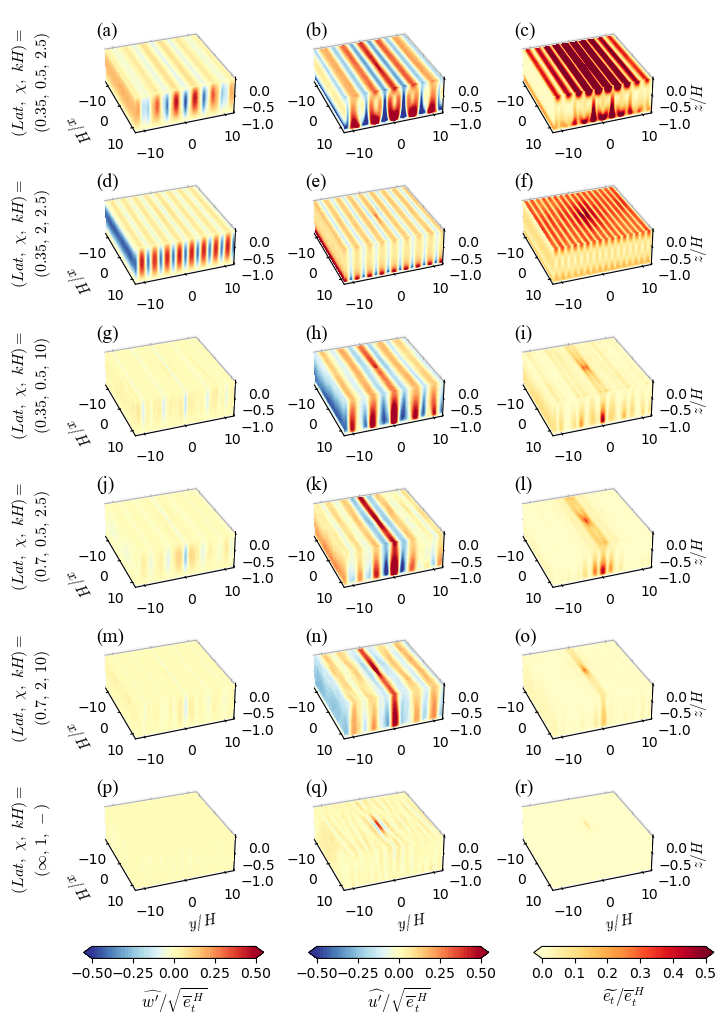

In [2]:
# ============================================================
# 7. Figure / GridSpec
# ============================================================
plt.rcParams['mathtext.fontset'] = 'cm'

fig = plt.figure(figsize=(7.5, 10))
gs = fig.add_gridspec(6, 3, wspace=0.0, hspace=0.05)
fig.subplots_adjust(left=0.12, right=0.955, top=0.997, bottom=0.095)

# ============================================================
# 8. Contour settings
# ============================================================
kw = {
    'vmin': -0.5,
    'vmax': 0.5,
    'levels': np.linspace(-0.5, 0.5, 51),
    'cmap': plt.get_cmap("RdYlBu_r"),
    'extend': 'both'
}

kw2 = {
    'vmin': 0,
    'vmax': 0.5,
    'levels': np.linspace(0,0.5, 51),
    'cmap': plt.get_cmap("YlOrRd"),
    'extend': 'both'
}

# ============================================================
# 9. Case information
# ============================================================
cases = [
    (r"$(0.35,\,0.5,\,2.5)$", data_norm[0]["u_E"],
     data_norm[0]["w"], tke_norm[0]),

    (r"$(0.35,\,2,\,2.5)$", data_norm[1]["u_E"],
     data_norm[1]["w"], tke_norm[1]),

    (r"$(0.35,\,0.5,\,10)$", data_norm[2]["u_E"],
     data_norm[2]["w"], tke_norm[2]),

    (r"$(0.7,\,0.5,\,2.5)$", data_norm[3]["u_E"],
     data_norm[3]["w"], tke_norm[3]),

    (r"$(0.7,\,2,\,10)$", data_norm[4]["u_E"],
     data_norm[4]["w"], tke_norm[4]),

    (r"$(\infty,\,1,\,-)$", data_norm[5]["u_E"],
     data_norm[5]["w"], tke_norm[5])
]

letters = list("abcdefghijklmnopqr")

# ============================================================
# 10. Draw all panels
# ============================================================
axes = []
cax_u = cax_w = cax_tke = None

for i, (case_label, du, dw, tke) in enumerate(cases):

    row = i

    # u_E'
    ax = fig.add_subplot(gs[row, 1], projection='3d')
    cax_u = plot_field3d(
        ax, x_1d, y_1d, zuv_1d, du, kw
    )
    axes.append(ax)

    ax.text2D(
        0.02, 0.92,
        f"({letters[i*3+1]})",
        fontfamily='Times New Roman',
        transform=ax.transAxes,
        fontsize=14,
        va='top'
    )

    # w'
    ax = fig.add_subplot(gs[row, 0], projection='3d')
    cax_w = plot_field3d(
        ax, x_1d, y_1d, zw_1d, dw, kw
    )
    axes.append(ax)

    ax.text2D(
        0.02, 0.92,
        f"({letters[i*3]})",
        transform=ax.transAxes,
        fontsize=14,
        fontfamily='Times New Roman',
        va='top'
    )

    ax.text2D(
        -0.43, 0.50,
        r"$(Lat,\ \chi,\ kH) =$" + "\n" + case_label,
        transform=ax.transAxes,
        rotation=90,
        va='center',
        ha='center',
        fontsize=11.5,
        fontweight='bold'
    )

    # TKE
    ax = fig.add_subplot(gs[row, 2], projection='3d')
    cax_tke = plot_field3d_tke(
        ax, x_1d, y_1d, zuv_1d, tke, kw2
    )
    axes.append(ax)

    ax.text2D(
        0.02, 0.92,
        f"({letters[i*3+2]})",
        transform=ax.transAxes,
        fontsize=14,
        fontfamily='Times New Roman',
        va='top'
    )

# ============================================================
# 11. Axis labels
# ============================================================
for ax in axes[1::3]:
    ax.set_xlabel(r'$x/H$', fontsize=11, labelpad=3)

axes[15].set_ylabel(r'$y/H$', fontsize=11, labelpad=3)
axes[16].set_ylabel(r'$y/H$', fontsize=11, labelpad=3)
axes[17].set_ylabel(r'$y/H$', fontsize=11, labelpad=3)

for ax in axes[2::3]:
    ax.text2D(
        1.3, 0.40,
        r'$z/H$',
        transform=ax.transAxes,
        rotation=90,
        fontsize=11,
        va='center',
        ha='center'
    )

for ax in axes:
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=10,
        pad=1
    )
    ax.tick_params(
        axis='z',
        which='major',
        labelsize=10,
        pad=1
    )

# ============================================================
# 12. Colorbars
# ============================================================
cbar_ax_u = fig.add_axes([0.45, 0.048, 0.24, 0.012])
cbar_ax_w = fig.add_axes([0.15, 0.048, 0.24, 0.012])
cbar_ax_tke = fig.add_axes([0.75, 0.048, 0.24, 0.012])

cbar_u = fig.colorbar(
    cax_u,
    cax=cbar_ax_u,
    orientation='horizontal',
    ticks=np.arange(-0.5, 0.51, 0.25)
)

cbar_w = fig.colorbar(
    cax_w,
    cax=cbar_ax_w,
    orientation='horizontal',
    ticks=np.arange(-0.5, 0.51, 0.25)
)

cbar_tke = fig.colorbar(
    cax_tke,
    cax=cbar_ax_tke,
    orientation='horizontal',
    ticks=np.arange(0, 0.51, 0.1)
)

for cb in [cbar_u, cbar_w, cbar_tke]:
    cb.ax.tick_params(labelsize=10, pad=2)

cbar_u.set_label(
    r"$\widehat{u'}/\sqrt{\overline{e}_t^{\,H}}$",
    fontsize=12,
    labelpad=3
)

cbar_w.set_label(
    r"$\widehat{w'}/\sqrt{\overline{e}_t^{\,H}}$",
    fontsize=12,
    labelpad=3
)

cbar_tke.set_label(
    r"$\widetilde{e_t}/\overline{e}_t^{\,H}$",
    fontsize=12,
    labelpad=3
)

# ============================================================
# 13. Save
# ============================================================
fig.savefig(
    "condAvg_3D_downwelling_TKE12LES_normalized.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()